In [1]:
from sedona.spark import SedonaContext
import matplotlib.pyplot as plt

In [2]:
%%capture
bucket_name = "apache-sedona-book"

config = SedonaContext.builder()

sedona = SedonaContext.create(config.getOrCreate())

sedona.sparkContext.setLogLevel("ERROR")

sc = sedona.sparkContext
sedona.sparkContext.setCheckpointDir("checkpoint")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/10 22:44:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/10 22:44:50 WARN UDTRegistration: Cannot register UDT for org.geotools.coverage.grid.GridCoverage2D, which is already registered.
25/11/10 22:44:50 WARN SimpleFunctionRegistry: The function rs_union_aggr replaced a previously registered function.
25/11/10 22:44:50 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.geom.Geometry, which is already registered.
25/11/10 22:44:50 WARN UDTRegistration: Cannot register UDT for org.apache.sedona.common.S2Geography.Geography, which is already registered.
25/11/10 22:44:50 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.index.SpatialIndex, which is already registered.
25/11/10 22:44:50 WARN SimpleFunctionRegistry: The function st_envelop

In [3]:
hotspot_data = sedona.read.format("geoparquet").load("source_data/hot_spot/")

In [4]:
from sedona.spark import dataframe_to_arrow
import geopandas as gpd
 
gdf = gpd.GeoDataFrame.from_arrow(dataframe_to_arrow(hotspot_data))

<Axes: >

<Figure size 1800x600 with 0 Axes>

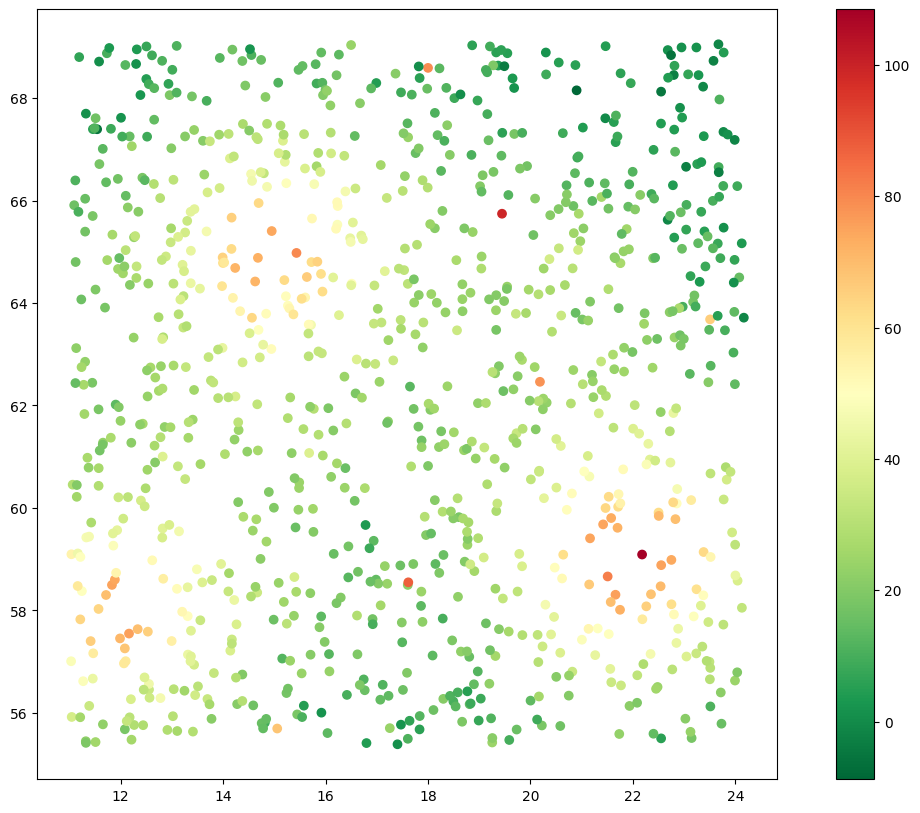

In [13]:
axis = plt.figure(figsize=(18, 6))

gdf.plot(column='value', cmap='RdYlGn_r', figsize=(15, 10), legend=True)

# calculate weights dataframe 

In [7]:
from sedona.spark.stats.weighting import add_distance_band_column
from sedona.spark.stats.hotspot_detection.getis_ord import g_local

In [8]:
weights_df = add_distance_band_column(
    dataframe=hotspot_data,
    threshold=2.0,
    include_self=True
)

In [9]:
gi_df = g_local(
    dataframe=weights_df,
    x="value",
    star=True
)

In [10]:
gi_df.show()

+------------------+---+--------------------+--------------------+--------------------+-----+--------------------+-------------------+--------------------+
|             value| id|                geom|             weights|                   G|   EG|                  VG|                  Z|                   P|
+------------------+---+--------------------+--------------------+--------------------+-----+--------------------+-------------------+--------------------+
|  32.6769782024205|962|POINT (14.2086082...|[{{31.59654843310...| 0.08039049257456365|0.068|2.419901599098762E-5|  2.518776997494963|0.005888160734531689|
|10.380113880690935|892|POINT (21.9289022...|[{{9.012815328494...|0.036026480451262284|0.075|2.648962910841274...| -7.572367593484635|1.831867990631508...|
| 47.13653775298749|607|POINT (15.7783621...|[{{21.07766507164...| 0.09545531061849963|0.066|2.353768211544497...|  6.071300939016648|6.343908731665238...|
| 72.56629508680625|487|POINT (14.6787141...|[{{31.22114109986..

# plot result

In [ ]:
hotspot_gdf = gpd.GeoDataFrame.from_arrow(dataframe_to_arrow(gi_df))

In [23]:
hotspot_gdf["type"] = hotspot_gdf["Z"].apply(lambda x: 1 if x > 2.48 else -1 if x < -2.48 else 0)

<Axes: >

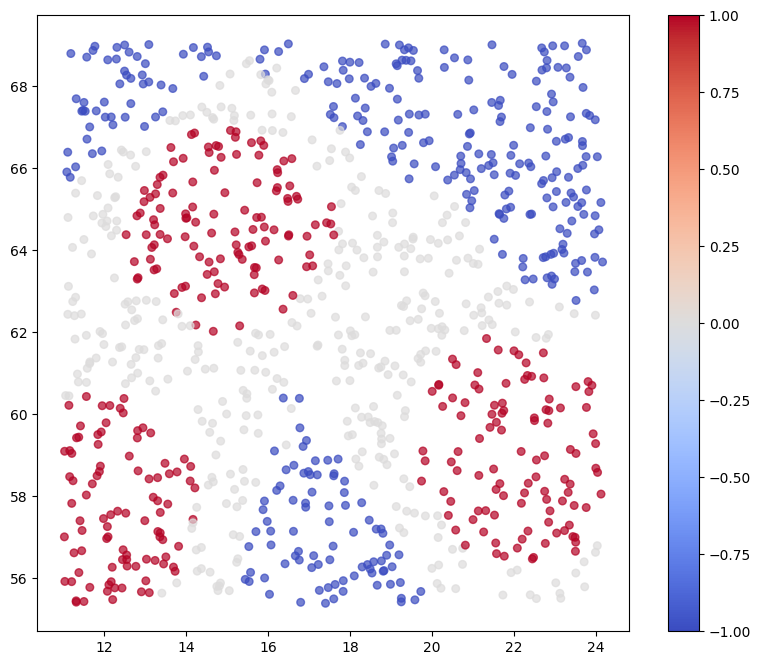

In [24]:
hotspot_gdf.plot(column='type', cmap='coolwarm', figsize=(10,8), legend=True, marker='o', markersize=30, alpha=0.7)

### 

<Axes: >

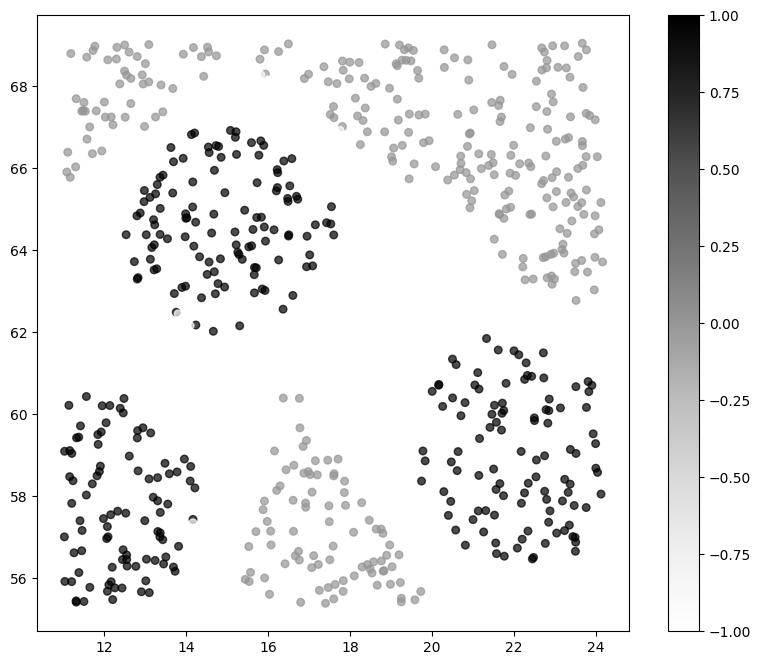

In [25]:
hotspot_gdf["type"] = hotspot_gdf["Z"].apply(lambda x: 1 if x > 2.48 else 0 if x < -2.48 else -1)

hotspot_gdf.plot(column='type', cmap='Greys', figsize=(10,8), legend=True, marker='o', markersize=30, alpha=0.7)